# Worksheet: Feed-Forward Architectures

**Topic:** Feed-Forward Architectures / Multi-Layer Perceptrons


## Learning goals

By the end of this worksheet, students should be able to:

1. Explain what a neuron does.
2. Compute a weighted sum \(z\).
3. Apply common activation functions.
4. Interpret a feed-forward architecture.
5. Count the number of trainable parameters.
6. Build a simple feed-forward network in Tensorflow Keras.


# 0a. Linear Regression as a Neural Network

Linear regression can be viewed as the simplest neural network: a single neuron that computes a weighted sum of the inputs plus a bias and uses a linear activation, producing a continuous output.

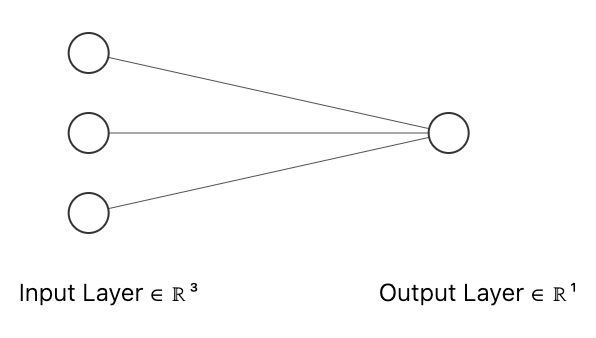

In [2]:
import numpy as np

## Let x1: square footage
x1 = 3000

## Let x2: # bedrooms
x2 = 4

## Let x3: distance of city
x3 = 5

## Neural Net can approximate a linear regression

#### 1) SUM
w1 = 1000  ## randomly assigned
w2 = -500
w3 = 10
b = 1.5

z = w1*x1 + w2*x2 + w3*x3 + b  ## b1*x1 + b2*x2 + b3*x3 + b0

print(f'The SUM computation in the single neuron outputs {z}')

#### 2) ACTIVATION
##### depends on the activation function chosen:
##### suppose we use a(z) = z  -----  linear activation function

def linear(z):
  return z

a = linear(z)

print(f'The ACTIVATION computation in the single neuron outputs {a}')

The SUM computation in the single neuron outputs 2998051.5
The ACTIVATION computation in the single neuron outputs 2998051.5


# 0b. Logistic Regression as a Neural Network

Logistic regression can be viewed as a simple neural network: a single neuron that computes a weighted sum of the inputs plus a bias and then applies a sigmoid activation function to produce a probability between 0 and 1.

In [3]:
## Let x1: square footage
x1 = 3000

## Let x2: # bedrooms
x2 = 4

## Let x3: distance of city
x3 = 5

## let y = {1: sold next 10 days, 0: not sold}

#### weights and biased

#### 1) SUM
w1 = 0.05  ## randomly assigned
w2 = -0.01
w3 = 0.6
b = 0

z = w1*x1 + w2*x2 + w3*x3 + b
print(f'The SUM computation in the single neuron outputs {z}')

#### 2) ACTIVATION
###### sigmoid activation outputs values from 0 to 1.

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

a = sigmoid(z)

print(f'The ACTIVATION computation in the single neuron outputs {a}')

The SUM computation in the single neuron outputs 152.96
The ACTIVATION computation in the single neuron outputs 1.0


---

# 1. A neuron: weighted sum + activation

A basic neuron performs two steps:

1. Compute a weighted sum  
   
   $z = w_1x_1 + w_2x_2 + \cdots + w_px_p + b$
  

2. Apply an activation function  

   $a = g(z)$
   

## Practice: Compute the sum function

Suppose a home has the following features:

- `x1 = 2000` (square feet)
- `x2 = 2` (bedrooms)
- `x3 = 10` (distance to city)

Use:

- `w = [6.2, 12000, -550]`
- `b = 120000`

Complete the code below to compute the weighted sum `z` part of the neuron.

In [4]:
## Vectorized Neuron Computation

#### variables in a vector
x = np.array([2000, 2, 10])

#### weights are stacked in a vector
w = np.array([6.2, 12000, -550])

#### bias
b = 120000

#### 1) SUM
z = w.dot(x) + b

#### 2) ACTIVATION
a = linear(z)

#### NEURON
neuron_output = linear(w.dot(x) + b)

print(f'The neuron output is {neuron_output}')

The neuron output is 150900.0


## Practice 1A: Manual perceptron question

Use the values below:

- `x1 = 3`
- `x2 = 2`
- `x3 = 6`

Suppose:

- `w1 = 0.5`
- `w2 = -1.2`
- `w3 = 0.8`
- `b = 1.0`

Compute the sum:

$z = w_1x_1 + w_2x_2 + w_3x_3 + b$


Then round to 4 decimal places.

In [5]:
## variables
x = np.array([3, 2, 6])

## weights
w = np.array([0.5, -1.2, 0.8])

## bias
b = 1.

## SUM
z = w.dot(x) + b
z

np.float64(4.9)

---

# 2. Activation functions

Common activation functions include:

- **Linear**: good for regression output layers
- **ReLU**: common in hidden layers
- **Sigmoid**: common for binary classification output
- **Tanh**: bounded between -1 and 1
- **Softmax**: for multi-class classification output

## Practice 2A: Complete the activation functions

In [6]:
# TODO: complete each function

def linear(z):
    return z

def relu(z):
    return np.max((0,z))

def leaky_relu(z, alpha=0.05):
    return np.max( (alpha*z, z) )

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh_fn(z):
    return np.tanh(z)

In [7]:
z = 1.2

## example with leaky ReLU
leaky_relu(z)

np.float64(1.2)

## Practice 2B: Apply activations to a single value

Use:

\[
z = -3.87
\]

Compute:

1. linear(z)
2. ReLU(z)
3. leaky ReLU(z) with \(\alpha = 0.05\)
4. sigmoid(z)
5. tanh(z)

In [8]:

z_value = -3.87

# TODO: replace None with your outputs
ans_linear = linear(z_value)
ans_relu = relu(z_value)
ans_leaky = leaky_relu(z_value)
ans_sigmoid = sigmoid(z_value)
ans_tanh = tanh_fn(z_value)

print("linear :", ans_linear)
print("relu   :", ans_relu)
print("leaky  :", ans_leaky)
print("sigmoid:", ans_sigmoid)
print("tanh   :", ans_tanh)

linear : -3.87
relu   : 0.0
leaky  : -0.1935
sigmoid: 0.020432187314053014
tanh   : -0.999130235259758


## Practice 2C: Concept check

Fill in the blanks:

1. The most common hidden-layer activation in modern feed-forward networks is **_____**.
2. A common output activation for a binary classification problem is **_____**.
3. A common output activation for a multi-class problem is **_____**.
4. A common output activation for regression is **_____**.

**Your answers here:**  
1.  ReLU
2.  Sigmoid
3.  Softmax
4.  Linear

---

# 3. Feed-forward architecture

In a feed-forward network, information moves in one direction:

**input layer → hidden layer(s) → output layer**

There are no cycles in the basic architecture.

## Practice 3A: Count hidden layers

Consider the architecture below conceptually:

- Input layer: 6 variables
- Hidden layer 1: 8 neurons
- Hidden layer 2: 4 neurons
- Output layer: 1 neuron

This architecture has 2 hidden layers

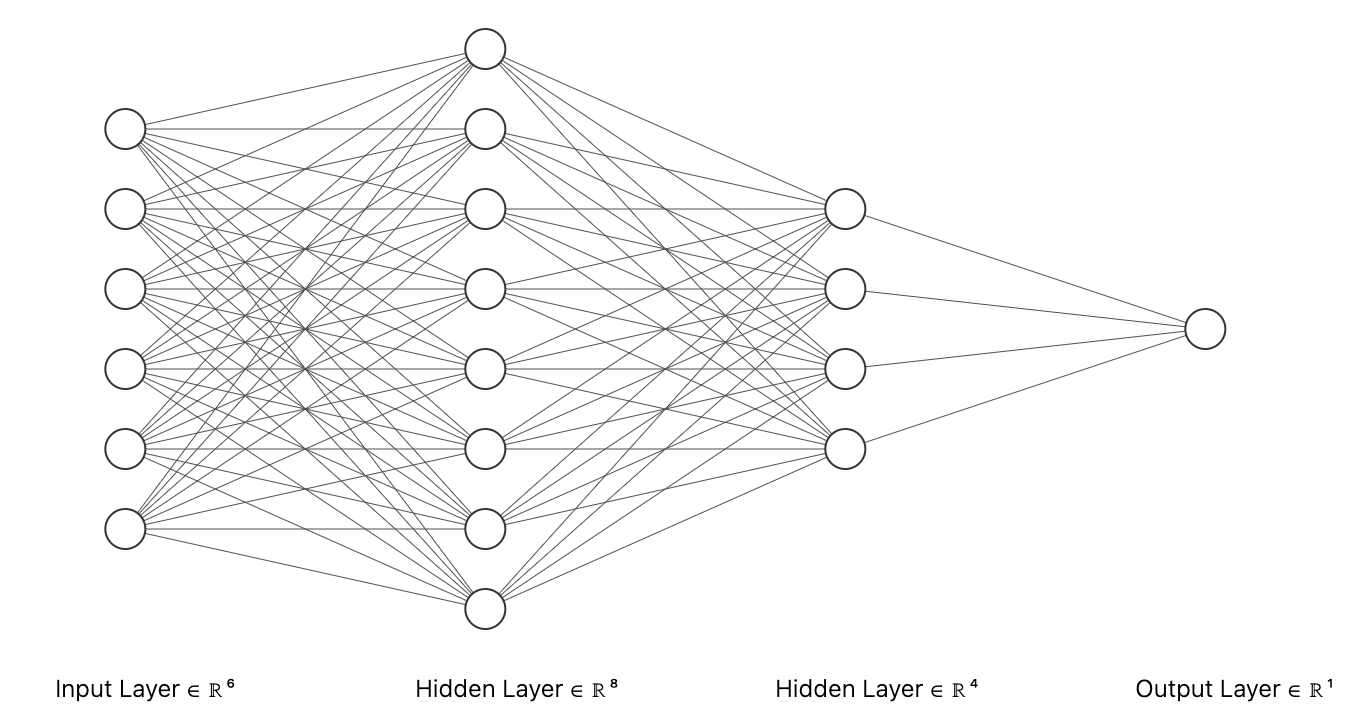

## Practice 3B: Architecture interpretation

Suppose a network has:

- 12 input variables
- 2 hidden layers with 10 and 5 neurons
- output layer with 3 neurons using softmax

Answer in the Markdown cell below:

1. What type of problem is this likely solving?
2. Why would the output layer have 3 neurons?

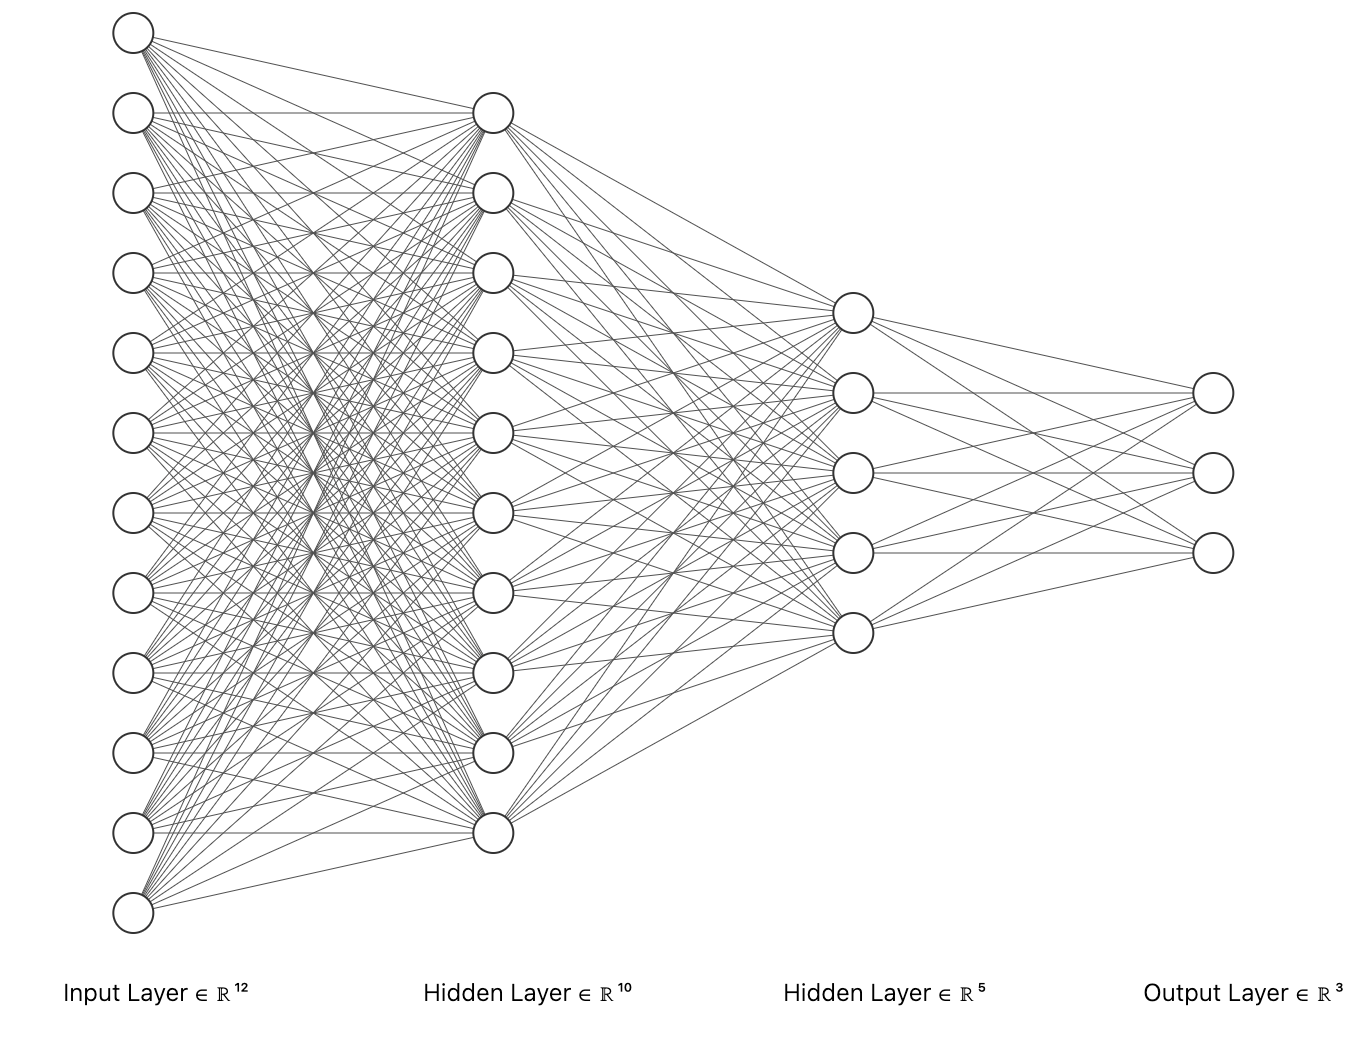

**Your response here:**  
1.  Multi-class because of the softmax activation in the output
2.  It needs the number of neurons equal to the number of classes

---

# 4. Counting parameters

For a dense layer:

- weights = (number of inputs) × (number of neurons)
- biases = (number of neurons)

So total trainable parameters for one dense layer:


$\text{parameters} = (\text{inputs} \times \text{neurons}) + \text{neurons}$


## Practice 4A: One hidden layer + multi-class output

Suppose we have:

- 13 input variables
- 10 neurons in one hidden layer
- 4 output neurons for a multi-class classification problem

Compute the total number of trainable parameters.

In [9]:
# TODO: compute total_params_mc

n_inputs = 13
n_hidden = 10
n_outputs = 4

total_params_mc = 13*10+10 + 10*4+4

print("Total parameters =", total_params_mc)

Total parameters = 184


## Practice 4B: One hidden layer + regression output

Suppose we have:

- 10 input variables
- 6 neurons in one hidden layer
- 1 output neuron for regression

Compute the total number of trainable parameters.

In [10]:
# TODO: compute total_params_reg

n_inputs = 10
n_hidden = 6
n_outputs = 1

total_params_reg = 10*6+6 + 6*1+1

print("Total parameters =", total_params_reg)

Total parameters = 73


---

# 5. Keras / TensorFlow example

Let $y = price$


In [ ]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/martinwg/ISA630/refs/heads/master/data/NN_house_prices.csv')
df.head()

,square_feet,bedrooms,distance_to_city,price
0,2174,4,24.1,335078
1,1952,4,10.0,362952
2,2227,4,7.9,398657
3,2533,4,21.8,378778
4,1918,3,6.4,363453


## Practice 5A: Define a feed-forward network in Keras

Answer in the Markdown cell below:

1. How many neurons should the Input layer have?
2. What should the output layer activation function be?



**Your response here:**  
1.  3
2. linear


## Practice 5B: Define a feed-forward network in Keras

Build a network with:

- first hidden layer = 16 neurons, ReLU
- second hidden layer = 8 neurons, tanh

Remember to include the Input and Output layers

print summary for total trainable parameters

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(3,)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='tanh'))
model.add(Dense(1, activation='linear'))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

## Practice 5C: Think before fitting

Answer these questions:

1. Could the `relu` activation function be used in the output layer for this problem?
2. How many trainable parameters are in the first hidden layer?

**Your response here:**  
1.  Yes
2.  3*16 + 16 = 64

In [12]:
3*16 + 16

64

# 6. Keras / TensorFlow example # 2

Let $y = $ customer_segment, which can be \{basic, standard, premium\}.

In [13]:
import pandas as pd

df2 = pd.read_csv('https://raw.githubusercontent.com/martinwg/ISA630/refs/heads/master/data/NN_customer_segment.csv')
df2.head()

,monthly_spend,website_visits,support_tickets,customer_segment
0,368.01,14,4,Basic
1,659.63,24,3,Standard
2,559.62,18,4,Basic
3,309.12,11,3,Basic
4,439.00,29,1,Standard


## Practice 6A: Define a feed-forward network in Keras

Build a network with:

- first hidden layer = 16 neurons, ReLU
- second hidden layer = 8 neurons, tanh

Remember to include the Input and Output layers

print summary for total trainable parameters

In [14]:
model2 = Sequential()
model2.add(Input(shape=(3,)))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(8, activation='tanh'))
model2.add(Dense(3, activation='softmax'))
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227 (908.00 B)

 Trainable params: 227 (908.00 B)

 Non-trainable params: 0 (0.00 B)

---

# 6. Quiz Review

Complete the following without using the self-check cells right away.

### Review 1
A neuron receives inputs `x = [2, -1, 4]`, weights `w = [0.3, 0.5, -0.2]`, and bias `b = 0.7`.  
Compute the weighted sum.

### Review 2
For `z = -2.4`, compute:
- ReLU
- sigmoid
- tanh

### Review 3
A feed-forward network has:
- 7 inputs
- one hidden layer with 5 neurons
- output layer with 3 neurons

How many trainable parameters does it have?

In [15]:
x = np.array([2, -1, 4])
w = np.array([0.3, 0.5, -0.2])
b = 0.7

z = w.dot(x) + b
print(z)

-1.1102230246251565e-16


In [18]:
z = -2.4

print(f'ReLU: {relu(z)}')
print(f'Sigmoid: {sigmoid(z)}')
print(f'Tanh: {tanh_fn(z)}')


ReLU: 0.0
Sigmoid: 0.08317269649392238
Tanh: -0.9836748576936802


In [19]:
7*5+5 + 5*3+3

58